In [1]:
import glob
%matplotlib widget
import matplotlib.pyplot as plt
import pandas as pd

## P control

Tune Kp until we get fixed oscillations. 
- Kp of 0.0020 results in a weaker response
- Kp of 0.0300 has its peaks growing towards instability
- Kp of 0.0150 as relatively stable oscillations

Note how with just Kp there is an error offset between the setpoint and the steady value of the response.

In [2]:
p_dfs = {}
for f in glob.glob('../out_data/p/*.csv'):
    file_name = f.split('\\')[1]
    print(file_name)
    p_dfs[file_name] = pd.read_csv(f)


pid_kp_0.0020_ki_0.0000_kd_0.0000.csv
pid_kp_0.0150_ki_0.0000_kd_0.0000.csv
pid_kp_0.0300_ki_0.0000_kd_0.0000.csv


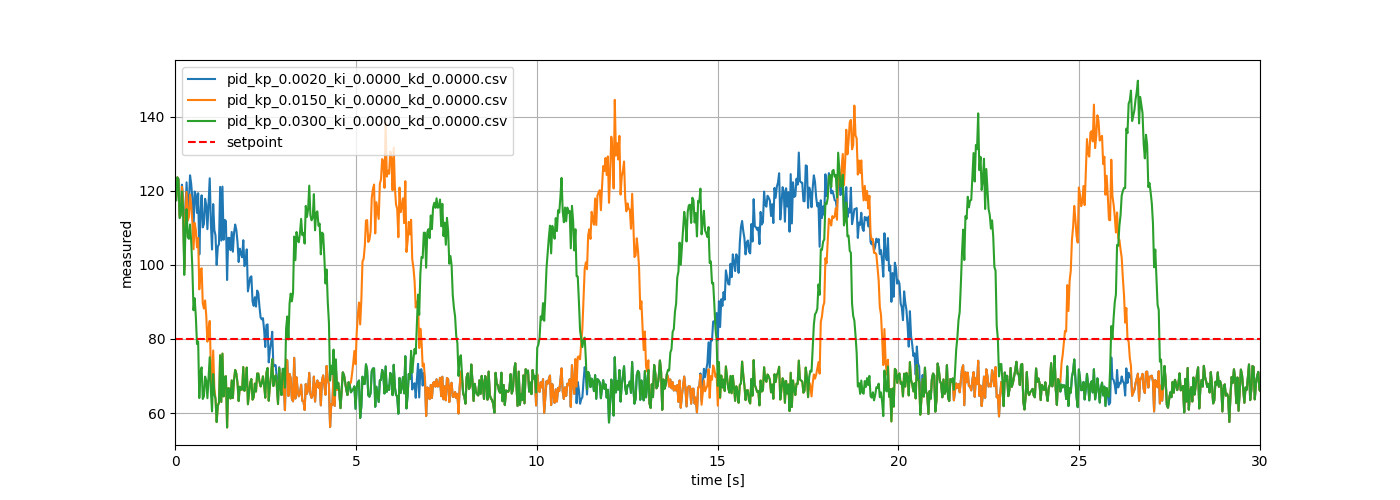

In [3]:
fig, ax = plt.subplots(figsize=(14, 5))

setpoint = next(iter(p_dfs.values()))["setpoint"].iloc[0]

for name, df in p_dfs.items():
    ax.plot(df["time"], df["measured"], label=name)

ax.axhline(y=setpoint, color='r', linestyle='--', linewidth=1.5, label='setpoint')
ax.set_xlim(0, 30.0)
ax.set_xlabel("time [s]")
ax.set_ylabel("measured")
ax.grid(True)

ax.legend()

In [4]:
## Plotting Function
import matplotlib.ticker as ticker

def plot_df(df, title):
    fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
    
    # Plot error over time
    axes[0].plot(
        df["time"],
        df["err"],
        linewidth=2,
        label=name + ' (error)'
    )
    axes[0].axhline(y=0, color='black', linestyle='-', linewidth=1.5)
    axes[0].set_ylabel("error")
    axes[0].set_title(title)
    axes[0].legend(fontsize=7)
    axes[0].grid(True)
    axes[0].xaxis.set_major_locator(ticker.MultipleLocator(1))
    
    
    # Plot rolling mean average over time
    axes[1].plot(
        df["time"],
        df["rolling_mean"],
        linewidth=2,
        label=name + ' (rolling mean error)'
    )
    
    axes[1].axhline(y=0, color='black', linestyle='-', linewidth=1.5)
    axes[1].set_xlabel("time [s]")
    axes[1].legend(fontsize=7)
    axes[1].grid(True)
    axes[1].set_xlim(0, 30.0)
    
    plt.tight_layout()
    plt.show()

#### Rolling mean
Because the response is noisy, plotting the rolling average helps reveal the underlying behavior more clearly.

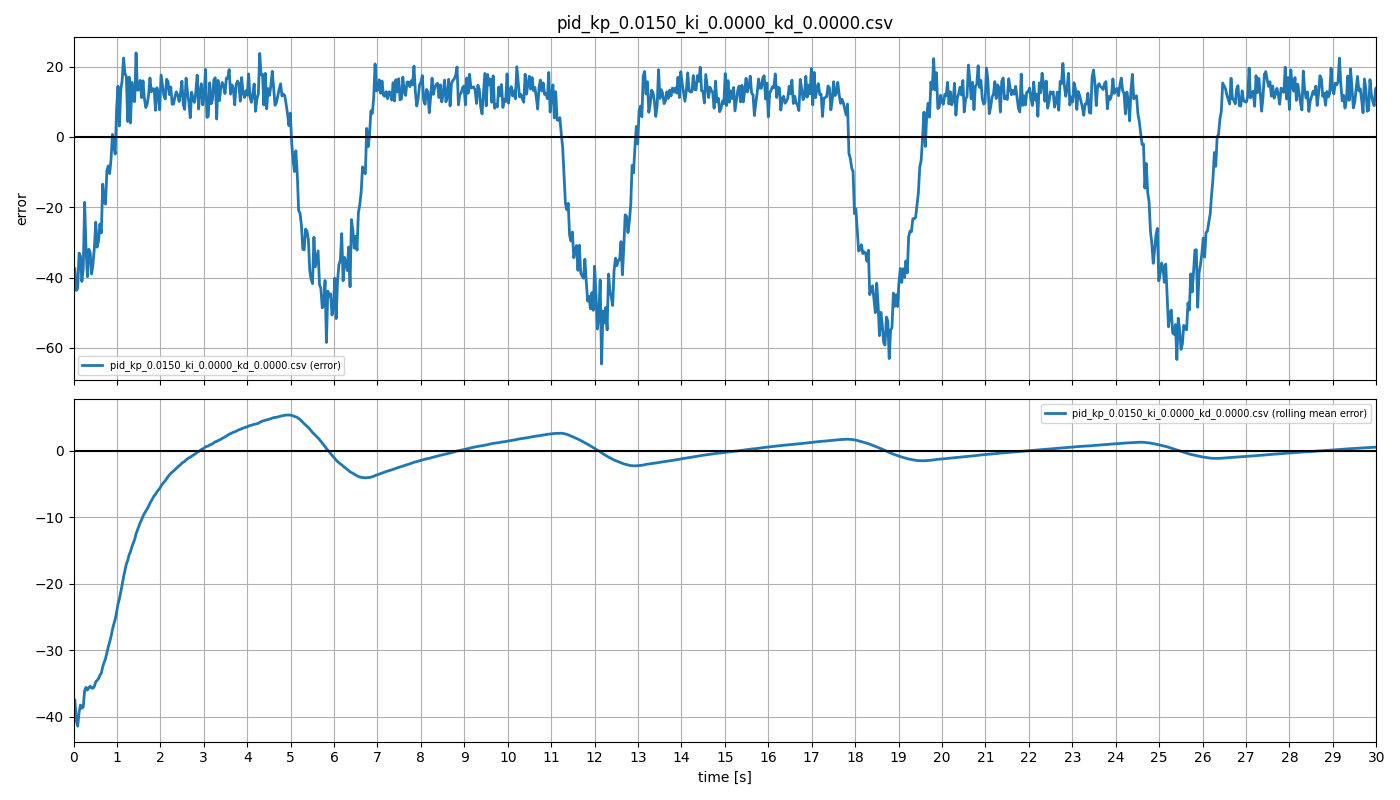

In [5]:
name = 'pid_kp_0.0150_ki_0.0000_kd_0.0000.csv'
p_df = p_dfs[name]

plot_df(p_df, name)

## Ziegler Nichols 
Given ultimate gain **Ku = 0.0150**, we can find ultimate period **Tu=~6.3** by measuring peak to peak.

| Controller | Kp        | Ki            | Kd          |
| ---------- | --------- | ------------- | ----------- |
| **P**      | 0.5 × Ku  | 0             | 0           |
| **PI**     | 0.45 × Ku | 1.2 × Kp / Tu | 0           |
| **PD**     | 0.8 × Ku  | 0             | Kp × Tu / 8 |
| **PID**    | 0.6 × Ku  | 2 × Kp / Tu   | Kp × Tu / 8 |


## PD Control

Kp = 0.8*Ku = 0.0120

Ki = 0

Kd = Kp * Tu / 8 =  0.00945

In [6]:
pd_dfs = {}
for f in glob.glob('../out_data/pd/*.csv'):
    file_name = f.split('\\')[1]
    print(file_name)
    pd_dfs[file_name] = pd.read_csv(f)

pid_kp_0.0120_ki_0.0000_kd_0.00945.csv


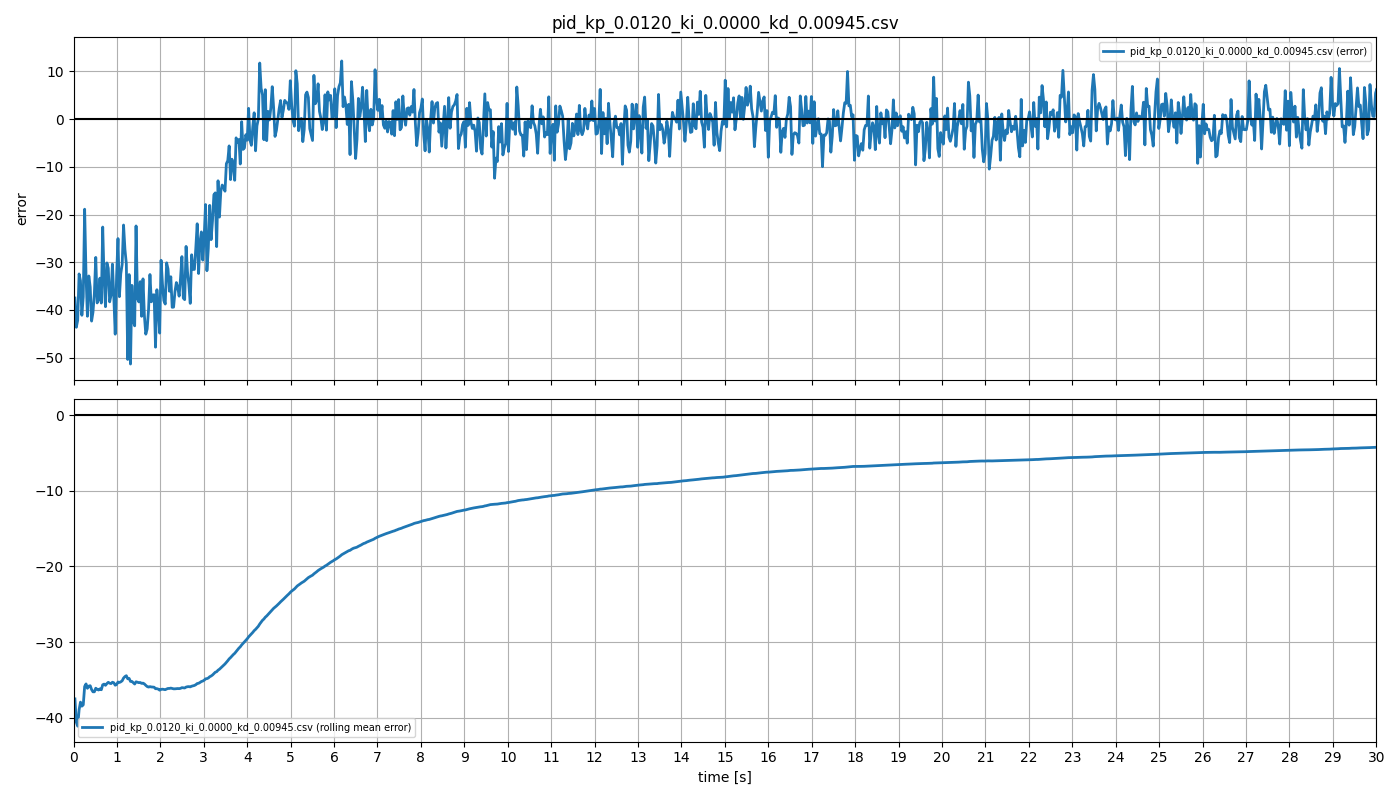

In [7]:
name = 'pid_kp_0.0120_ki_0.0000_kd_0.00945.csv'
pd_df = pd_dfs[name]

plot_df(pd_df, name)

## PID Control 


Kp = 0.6 × Ku = 0.00900

Ki = 2 × Kp / Tu = 0.00286

Kd = Kp × Tu / 8 = 0.00708

In [8]:
pid_dfs = {}
for f in glob.glob('../out_data/pid/*.csv'):
    file_name = f.split('\\')[1]
    print(file_name)
    pid_dfs[file_name] = pd.read_csv(f)

pid_kp_0.00900_ki_0.00286_kd_0.00708.csv
pid_kp_0.00900_ki_0.00286_kd_0.00708_alpha_0.2.csv


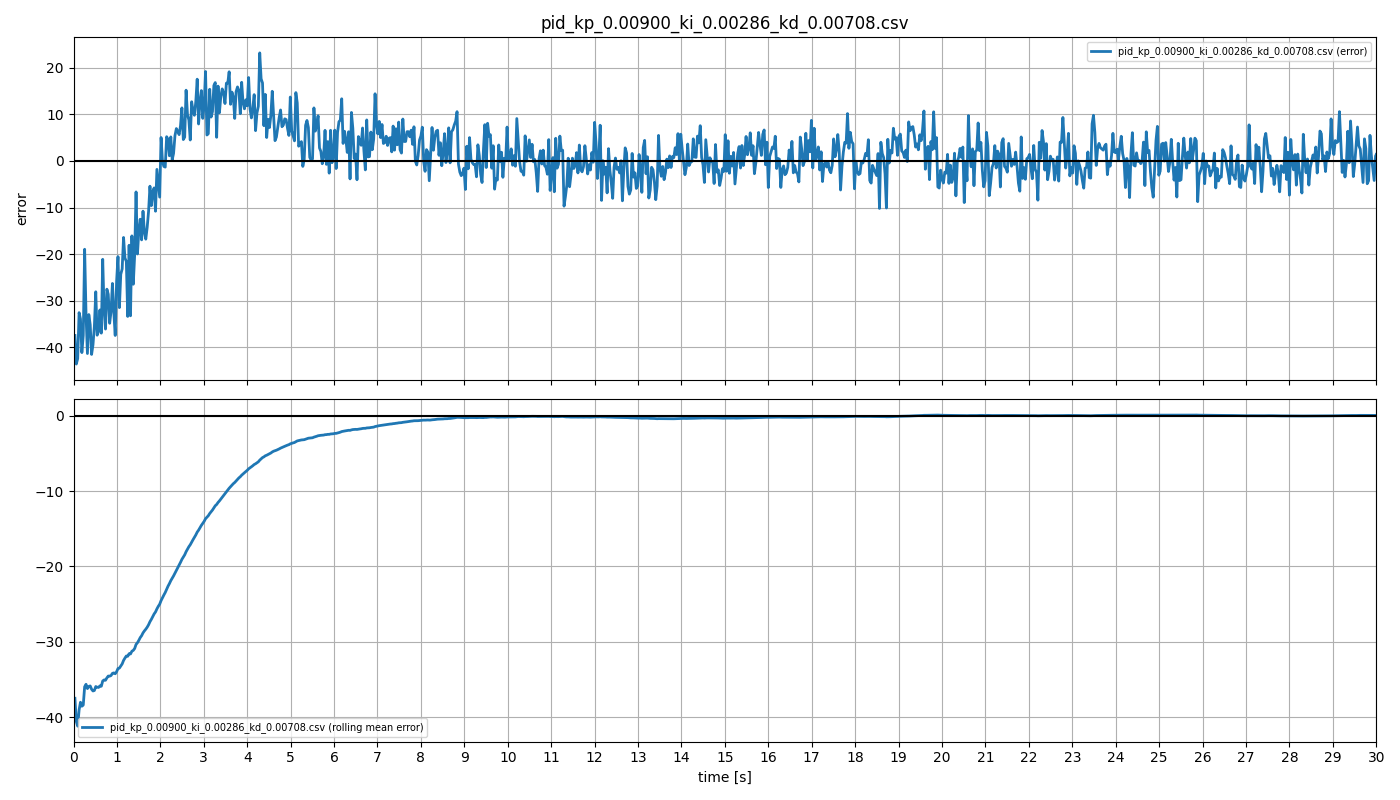

In [9]:
name = 'pid_kp_0.00900_ki_0.00286_kd_0.00708.csv'
pid_df = pid_dfs[name]

plot_df(pid_df, name)

### PID With Low-Pass Filter On The Derivative Term 
0 (full filtering) <= alpha <= 1.0 (no filtering)

Reduce noise by setting **alpha=0.2**

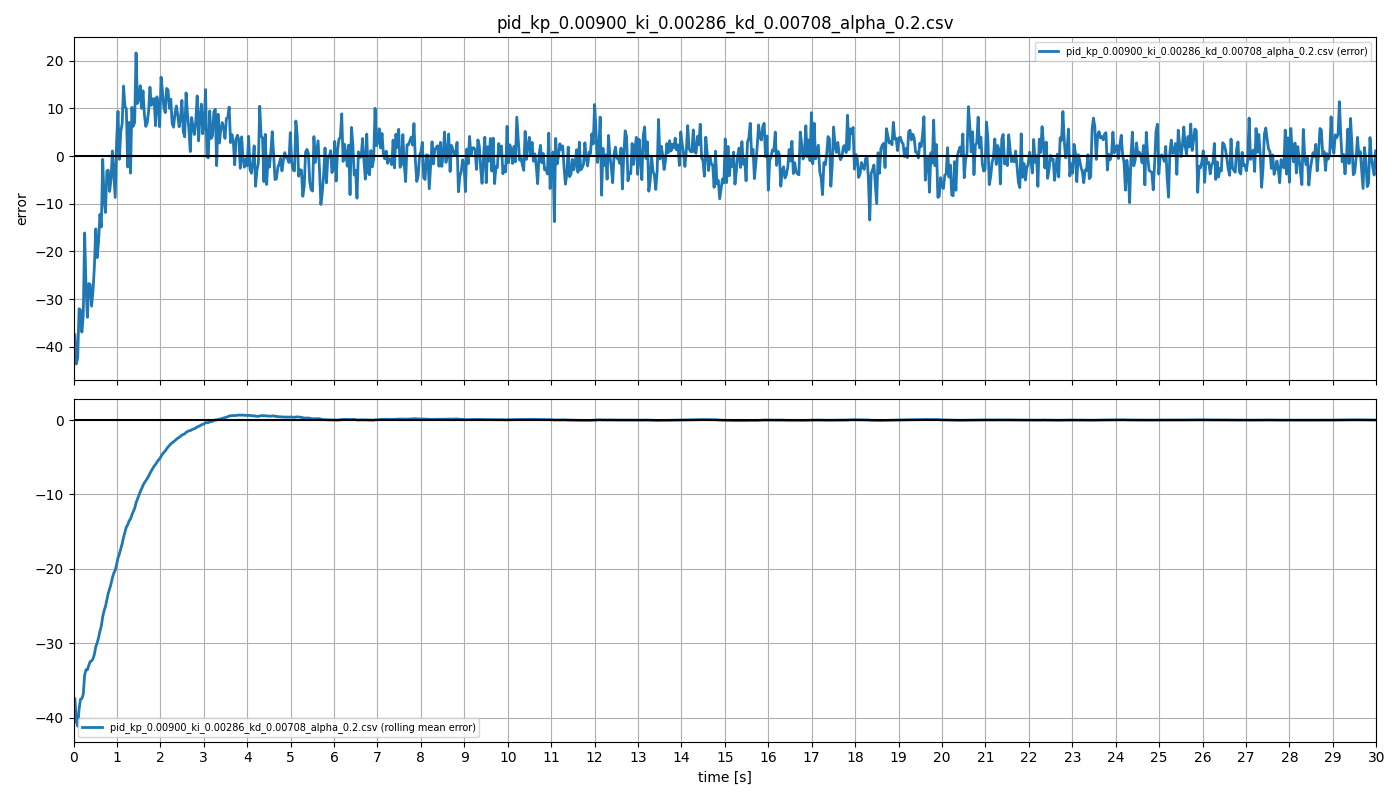

In [10]:
name = 'pid_kp_0.00900_ki_0.00286_kd_0.00708_alpha_0.2.csv'
pid_lpf_df = pid_dfs[name]

plot_df(pid_lpf_df, name)